# Tutorial: IEA-22 windIO blade -> OpenSG (worked example)

This notebook takes the **IEA-22-280-RWT** blade — the windIO v2 file that ships with the `windIO` package — feeds it through **OpenSG_io**, and shows exactly what comes out: the resolved cross-section, a plot, the **1D-shell SG YAML**, and the **PreVABS XML** for the 2D-solid.

In [1]:
import os, sys, tempfile
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))   # OpenSG_io repo root
import numpy as np, yaml, windIO
from opensg_io import load_blade, build_cross_section, emit_opensg_yaml, emit_prevabs

iea22 = os.path.join(os.path.dirname(windIO.__file__), 'examples', 'turbine', 'IEA-22-280-RWT.yaml')
OUT = tempfile.mkdtemp()
print('INPUT  windIO file :', os.path.basename(iea22))
print('OUTPUT directory   :', OUT)

INPUT  windIO file : IEA-22-280-RWT.yaml
OUTPUT directory   : C:\Users\bagla0\AppData\Local\Temp\tmp58ed2iky


## 1. Load the blade

`load_blade()` auto-detects the windIO version (v2 here -> `WindIOBlade`).

In [2]:
blade = load_blade(iea22)
print('reader            :', type(blade).__name__)
print('chord  @ r=0.5    : %.3f m' % blade.scalar('chord', 0.5))
print('twist  @ r=0.5    : %.3f deg' % blade.scalar('twist', 0.5))

reader            : WindIOBlade
chord  @ r=0.5    : 4.861 m
twist  @ r=0.5    : 1.159 deg


## 2. Resolve the cross-section at a station

`build_cross_section(blade, r)` resolves the airfoil, the layup stack on each arc segment, and the shear webs at non-dimensional span `r`.

In [3]:
cs = build_cross_section(blade, r=0.5, mesh_size=0.01)
print('station r=0.5  chord=%.3f m  laminates=%d  webs=%d'
      % (cs['chord'], len(cs['laminates']), len(cs['webs'])))
inv = {v: k for k, v in cs['laminates'].items()}
for k in range(len(inv)):
    plies = ' + '.join('%s@%g(%.4f)' % (m, a, t) for (m, t, a) in inv[k])
    print('  layup_%d: %s' % (k, plies[:84]))

station r=0.5  chord=4.861 m  laminates=6  webs=3
  layup_0: gelcoat@0(0.0005) + glass_triax@0(0.0030) + glass_uniax@0(0.0140) + glass_triax@0(0.
  layup_1: gelcoat@0(0.0005) + glass_triax@0(0.0030) + medium_density_foam@0(0.0425) + glass_tr
  layup_2: gelcoat@0(0.0005) + glass_triax@0(0.0030) + carbon_uniax@0(0.0670) + glass_triax@0(0
  layup_3: gelcoat@0(0.0005) + glass_triax@0(0.0030) + glass_uniax@0(0.0110) + glass_triax@0(0.
  layup_4: gelcoat@0(0.0005) + glass_triax@0(0.0030) + carbon_uniax@0(0.0660) + glass_triax@0(0
  layup_5: glass_biax@0(0.0020) + medium_density_foam@0(0.0300) + glass_biax@0(0.0020)


## 3. Visualise it

Each skin element is coloured by its laminate; the shear webs are drawn in black.

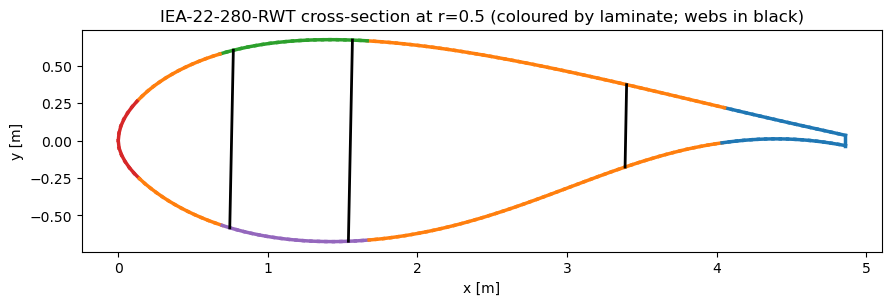

In [4]:
import matplotlib.pyplot as plt
nodes = np.asarray(cs['nodes'])
fig, ax = plt.subplots(figsize=(10, 3))
cmap = plt.get_cmap('tab10')
for (n1, n2), lam in zip(cs['elems'], cs['elem_lam']):
    p1, p2 = nodes[n1], nodes[n2]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=cmap(lam % 10), lw=2.5)
for w in cs['webs']:
    pa, pb = nodes[w['a']], nodes[w['b']]
    ax.plot([pa[0], pb[0]], [pa[1], pb[1]], 'k-', lw=2)
ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('IEA-22-280-RWT cross-section at r=0.5 (coloured by laminate; webs in black)')
plt.tight_layout(); plt.show()

## 4. Output 1 -- the 1D-shell SG YAML

`emit_opensg_yaml(cs, path)` writes the OpenSG 1D-shell SG: nodes, line elements, element sets (= laminates), sections (the ply layups), materials, and per-element `e1/e2/e3` orientations. This feeds the MSG shell homogenizers (RM / Kirchhoff).

In [5]:
shell_path = os.path.join(OUT, 'iea22_r050_shell.yaml')
info = emit_opensg_yaml(cs, shell_path)
d = yaml.safe_load(open(shell_path))
print('1D-shell YAML:', os.path.basename(shell_path))
print('  nodes=%d  elements=%d  element-sets=%d  materials=%d'
      % (len(d['nodes']), len(d['elements']), len(d['sets']['element']), len(d['materials'])))
print('  example section (layup):')
print('   ', d['sections'][0])

1D-shell YAML: iea22_r050_shell.yaml
  nodes=274  elements=277  element-sets=6  materials=6
  example section (layup):
    {'type': 'shell', 'elementSet': 'layup_0', 'layup': [['gelcoat', 0.0005, 0.0], ['glass_triax', 0.003, 0.0], ['glass_uniax', 0.01402367, 0.0], ['glass_triax', 0.003, 0.0]]}


## 5. Output 2 -- the PreVABS XML (-> 2D-solid)

`emit_prevabs(cs, dir, name)` writes the PreVABS cross-section input (airfoil `.dat`, dividing points, layups, webs, materials). Running PreVABS on it gives a `.sg`, which `convert_sg_to_yaml` turns into the 2D-solid SG YAML for the FEniCS (VABS-equivalent) reference.

In [6]:
pv = os.path.join(OUT, 'iea22_r050_prevabs')
pinfo = emit_prevabs(cs, pv, name='iea22_r050')
print('PreVABS 2D-solid inputs in', os.path.basename(pv) + '/:')
for f in sorted(os.listdir(pv)):
    print('  ', f)

PreVABS 2D-solid inputs in iea22_r050_prevabs/:
   iea22_r050.dat
   iea22_r050.xml
   materials.xml


## Summary

From **one windIO file** OpenSG_io produced, at the chosen station:

| output | file | feeds |
|--------|------|-------|
| 1D-shell SG | `iea22_r050_shell.yaml` | MSG-RM / Kirchhoff (Timoshenko 6x6) |
| 2D-solid SG | `iea22_r050_prevabs/*.xml` -> `.sg` -> YAML | FEniCS 2D-solid (VABS-equivalent) |

Repeat over `r = 0.1 .. 0.95` (or use `scripts/opensg_io.py <blade.yaml> out --solid`) to get the whole blade, then cross-check shell-vs-solid at every station.